# Student Performance Classification

This notebook builds a Random Forest classifier for `FinalGrade` using `student_performance.csv`. The leakage-prone `ExamScore` feature is dropped before modeling.

Workflow:
1. Load and inspect the data
2. Perform exploratory data analysis
3. Preprocess the features
4. Train a Random Forest classifier
5. Plot feature importance and a confusion matrix
6. Print a classification report

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
DATA_PATH = "/Users/rosavo/Downloads/Course Portfolio/Student-Performance-Classifier/student_performance.csv"

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
display(df.head())

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("Target distribution:")
target_counts = df["FinalGrade"].value_counts().sort_index()
display(target_counts.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
class_colors = sns.color_palette("viridis", n_colors=len(target_counts))
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=class_colors)
axes[0].set_title("FinalGrade Class Distribution")
axes[0].set_xlabel("FinalGrade")
axes[0].set_ylabel("Count")

eda_df = df.drop(columns=["ExamScore"])
corr = eda_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlation Heatmap Without ExamScore")
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rosavo/Downloads/student_performance.csv'

In [9]:
# Drop the leakage-prone feature before modeling.
feature_columns = [column for column in df.columns if column not in ["FinalGrade", "ExamScore"]]
X = df[feature_columns].copy()
y = df["FinalGrade"].copy()

# Low-cardinality coded features are treated as categorical.
categorical_columns = [
    "Resources",
    "Extracurricular",
    "Motivation",
    "Internet",
    "Gender",
    "LearningStyle",
    "Discussions",
    "EduTech",
    "StressLevel",
]
numeric_columns = [column for column in X.columns if column not in categorical_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns),
    ]
)

base_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", base_model),
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="accuracy",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)
clf = search.best_estimator_

print("Best parameters:")
print(search.best_params_)
print(f"Best cross-validated accuracy: {search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/rosavo/Downloads/archive/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rosavo/Downloads/archive/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rosavo/Downloads/archive/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rosavo/Downloads/arch

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': None}
Best cross-validated accuracy: 0.8540


In [10]:
y_pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)

print(f"Test accuracy: {test_accuracy:.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))

Test accuracy: 0.9240
Classification report:
              precision    recall  f1-score   support

           0     0.9130    0.9452    0.9288       766
           1     0.9412    0.8943    0.9171       662
           2     0.9422    0.9227    0.9323       724
           3     0.9015    0.9307    0.9158       649

    accuracy                         0.9240      2801
   macro avg     0.9245    0.9232    0.9235      2801
weighted avg     0.9245    0.9240    0.9239      2801



,feature,importance
0,num__AssignmentCompletion,0.166202
1,num__StudyHours,0.155708
2,num__Attendance,0.153629
3,num__OnlineCourses,0.136526
4,num__Age,0.116104
5,cat__LearningStyle_3,0.021038
6,cat__LearningStyle_2,0.020746
7,cat__LearningStyle_1,0.020298
8,cat__Gender_0,0.019467
9,cat__LearningStyle_0,0.019441


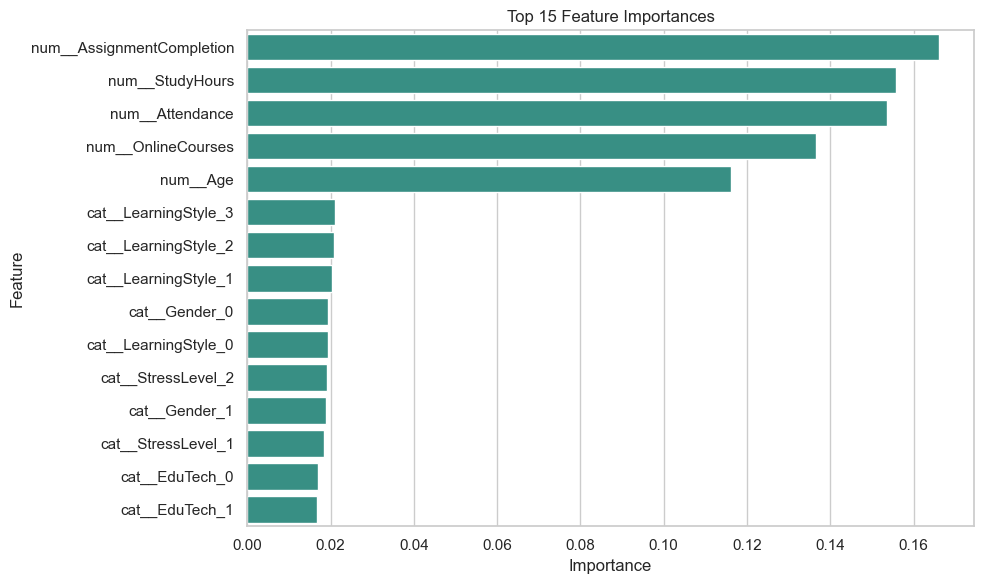

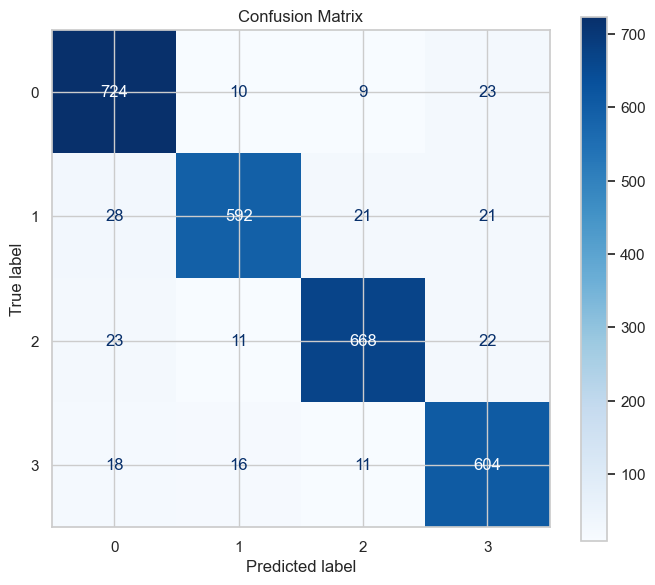

In [11]:
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
importances = clf.named_steps["model"].feature_importances_
importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="#2a9d8f")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

class_labels = [str(label) for label in sorted(y.unique())]
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_labels,
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title("Confusion Matrix")
plt.tight_layout()

## Next Steps

If you want to iterate further, you can try hyperparameter tuning, compare with gradient boosting models, or convert the notebook into a reusable training script.